In [ ]:
import pandas as pd

# 1.通过list 创建DataFrame
print("通过list创建的DataFrame:")
data_list = [
    ['600877.SH', 11.33],
    ['300922.SZ', 12.9],
    ['002421.SZ', 2.38]
]
df1 = pd.DataFrame(data_list, columns=['stockCode', 'openingPrice'])
print(df1)

# 2.通过字典创建DataFrame
print("通过字典创建的DataFrame:")
data = {
    'stockCode': ['600877.SH', '300922.SZ', '002421.SZ'],
    'openingPrice': [11.33, 12.9, 2.38]
}
df2 = pd.DataFrame(data)
print(df2)

# 3.通过Series创建DataFrame
print("通过Series创建的DataFrame:")
stockCode = pd.Series(['600877.SH', '300922.SZ', '002421.SZ'])
openingPrice = pd.Series([11.33, 12.9, 2.38])
df3 = pd.DataFrame({'stockCode': stockCode, 'openingPrice': openingPrice})
print(df3)

# 4.通过复制df1创建
print("通过复制df1创建:")
df4 = df1.copy()  # 复制df1到新的DataFrame df4
print(df4)

In [ ]:
import pandas as pd

# 1.调整 header 参数。
df_header = pd.read_csv('Global EV Sales 2010-2024.csv', header=[0, 1])
df_header = df_header.iloc[:2, :3]
print("调整 header 参数:", df_header)

# 2.调整 usecols 参数。
df_usecols = pd.read_csv('Global EV Sales 2010-2024.csv', index_col=[2, 3], nrows=5)
print("调整 usecols 参数:", df_usecols)

# 3.调整 index_col 参数。
df_index_col = pd.read_csv('Global EV Sales 2010-2024.csv', index_col=[1, 2], nrows=5, usecols=[0, 1, 2])
print("调整 index_col 参数:", df_index_col)

# 4.其他 read_csv 操作。
df_others = pd.read_csv('Global EV Sales 2010-2024.csv', sep=',', skiprows=3, encoding='utf-8', nrows=5, usecols=[3, 4, 5])
print("其他 read_csv 操作:", df_others)

In [ ]:
import pandas as pd

# 1.只读取第4列和第8列的前3行数据
df_usecols = pd.read_excel('Journal Citation Reports 2024.xlsx', sheet_name=0, usecols=[3, 7], nrows=3)
print("调整 usecols 参数:", df_usecols)

# 2.将第1列和第2列设置为行索引
df_index_col = pd.read_excel('Journal Citation Reports 2024.xlsx', sheet_name='JCR', index_col=[0, 1], nrows=3, usecols=[0, 1, 6])
print("调整 index_col 参数:", df_index_col)

# 3.跳过前7行数据，读取第1列和第7列的前三行数据，并指定列名
df_names = pd.read_excel('Journal Citation Reports 2024.xlsx', sheet_name='JCR', skiprows=7, nrows=3, usecols=[0, 6], names=['Name', 'Score'])
print("其他 read_excel 操作:", df_names)

In [ ]:
import pandas as pd
# 创建一个包含缺失值的DataFrame
data = {
    'A': [1, 2, None, 4],
    'B': [5, None, 7, 8],
    'C': [9, 10, 11, None]
}
df = pd.DataFrame(data)
print(df)

# 删除包含缺失值的行
df_dropped = df.dropna()
print("删除缺失值的行后：")
print(df_dropped)

# 使用众数填充缺失值
df_mode_filled = df.fillna(df.mode().iloc[0])
print("使用众数填充后：")
print(df_mode_filled)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 从Excel读取数据
df = pd.read_excel('data_imputation.xlsx')

X = df['X'].values
y = df['y'].values

# 使用np.polyfit二次多项式拟合
X_clean = X[~np.isnan(y)]
y_clean = y[~np.isnan(y)]
coefficients = np.polyfit(X_clean, y_clean, deg=2)
poly = np.poly1d(coefficients)  # 使用np.poly1d将系数转换为多项式函数

# 计算拟合值，用拟合值替代缺失值
y_fit = poly(X)
y_filled = np.where(np.isnan(y), y_fit, y)

# 绘制原始数据、拟合曲线和补齐后的数据
plt.scatter(X, y, label='Original Data')
plt.plot(X, y_fit, label='Fitted Curve')
plt.scatter(X, y_filled, label='Imputed Data', marker='x')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer

# 1.读取 Excel 文件
df = pd.read_excel("sales_data.xlsx")

# 2.等宽分箱
bins_width = pd.cut(df['Sales'], bins=6)
width_bin_counts = bins_width.value_counts().sort_index()

# 3.等深分箱
k_bins_discretizer = KBinsDiscretizer(n_bins=6, encode='ordinal', strategy='quantile')
sales_binned_depth = k_bins_discretizer.fit_transform(df[['Sales']])
df['Depth_Bin'] = sales_binned_depth.astype(int)
depth_bin_counts = df['Depth_Bin'].value_counts().sort_index()

In [ ]:
import pandas as pd
import numpy as np

# 1.读取数据
df = pd.read_excel('noisy_sin_data.xlsx')
dates = df['Date']
X = np.linspace(0, 10, len(dates))

y = df['y'].values

# 2.更高阶的多项式拟合
coefficients = np.polyfit(X, y, deg=9)   
poly = np.poly1d(coefficients)

# 3.计算拟合值，进行降噪
y_fit = poly(X)

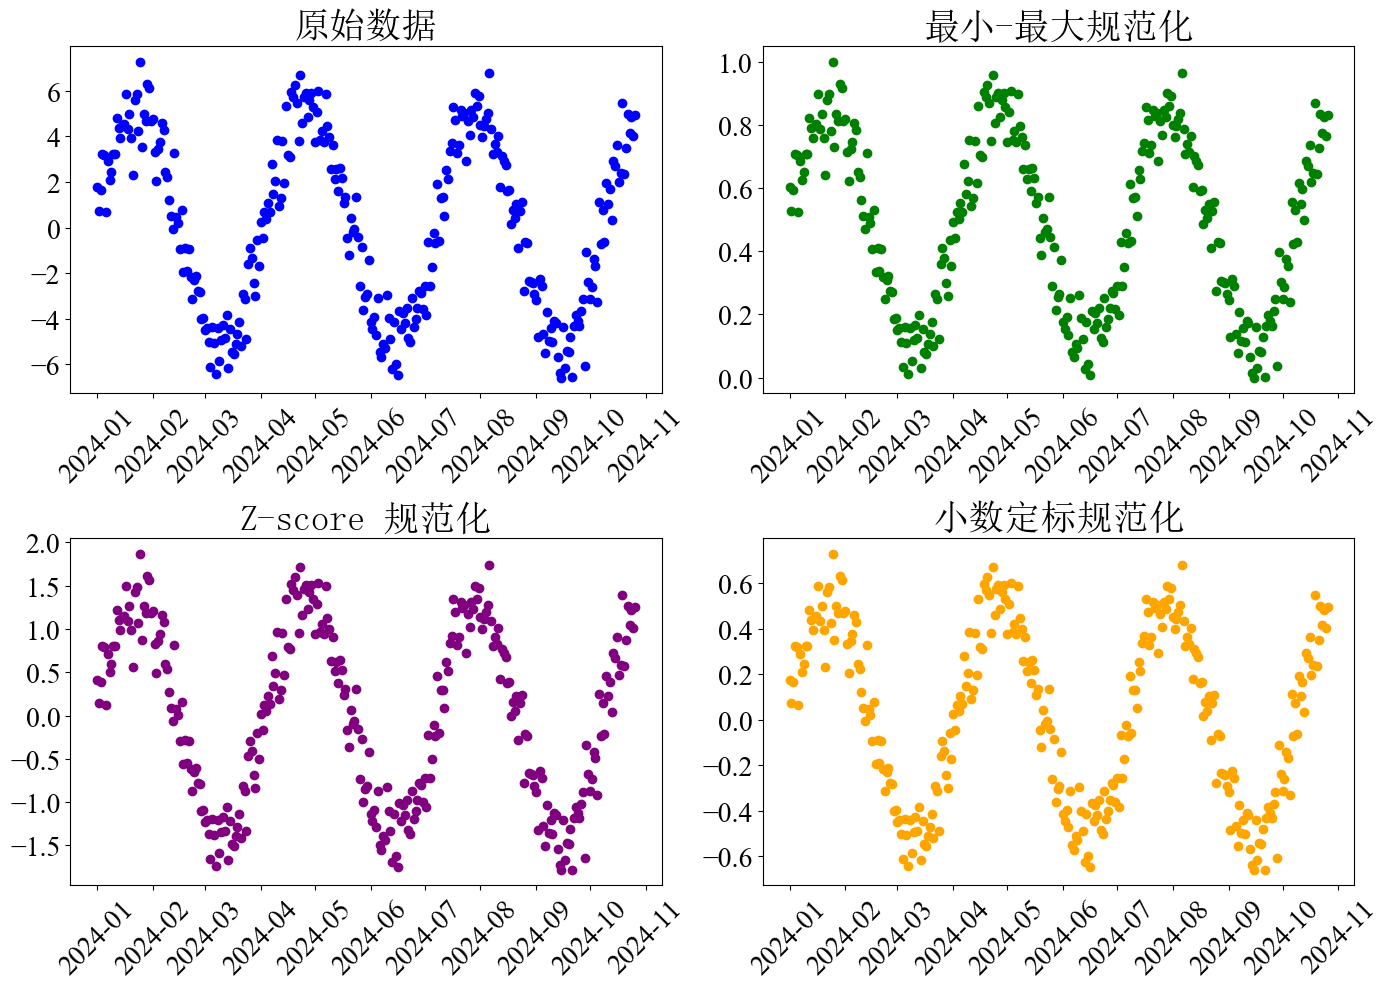

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from matplotlib.font_manager import FontProperties

# Load data from Excel
data = pd.read_excel('dataNormalization.xlsx')
dates = data['日期']
y_true = data['真实函数'].values
y_noisy = data['原始数据'].values

# Min-Max Normalization
scaler_minmax = MinMaxScaler()
dates_ordinal = dates.map(pd.Timestamp.toordinal).values.reshape(-1, 1)
dates_minmax = scaler_minmax.fit_transform(dates_ordinal)
y_noisy_minmax = scaler_minmax.fit_transform(y_noisy.reshape(-1, 1))

# Z-score Normalization
scaler_zscore = StandardScaler()
dates_zscore = scaler_zscore.fit_transform(dates_ordinal)
y_noisy_zscore = scaler_zscore.fit_transform(y_noisy.reshape(-1, 1))

# Decimal Scaling Normalization
def decimal_scaling(data):
    max_abs_value = np.max(np.abs(data))
    scaling_factor = np.ceil(np.log10(max_abs_value))
    return data / (10 ** scaling_factor)

dates_decimal = decimal_scaling(dates_ordinal)
y_noisy_decimal = decimal_scaling(y_noisy)

# Set fonts for Chinese (SimSun) and English/Numbers (Times New Roman)
font_path_zh = 'C:/Windows/Fonts/simsun.ttc'  # SimSun (宋体) font path
font_zh = FontProperties(fname=font_path_zh, size=26)
font_path_en = 'C:/Windows/Fonts/times.ttf'  # Times New Roman font path
font_en = FontProperties(fname=font_path_en, size=20)

# Visualization
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.scatter(dates, y_noisy, color='blue')
plt.title('原始数据', fontsize=28, fontproperties=font_zh)
plt.xticks(fontsize=20, rotation=45, fontproperties=font_en)
plt.yticks(fontsize=20, fontproperties=font_en)

plt.subplot(2, 2, 2)
plt.scatter(dates, y_noisy_minmax, color='green')
plt.title('最小-最大规范化', fontsize=28, fontproperties=font_zh)
plt.xticks(fontsize=20, rotation=45, fontproperties=font_en)
plt.yticks(fontsize=20, fontproperties=font_en)

plt.subplot(2, 2, 3)
plt.scatter(dates, y_noisy_zscore, color='purple')
plt.title('Z-score 规范化', fontsize=28, fontproperties=font_zh)
plt.xticks(fontsize=20, rotation=45, fontproperties=font_en)
plt.yticks(fontsize=20, fontproperties=font_en)

plt.subplot(2, 2, 4)
plt.scatter(dates, y_noisy_decimal, color='orange')
plt.title('小数定标规范化', fontsize=28, fontproperties=font_zh)
plt.xticks(fontsize=20, rotation=45, fontproperties=font_en)
plt.yticks(fontsize=20, fontproperties=font_en)

plt.tight_layout()
# 保存和显示图表
plt.tight_layout()
plt.savefig(r"F:\zhoumian\第五章svg\max.svg")  # 添加文件名和扩展名
plt.show()


In [ ]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# 1.创建数据集
data = pd.DataFrame({
    '植物ID': ['P1', 'P2', 'P3', 'P4', 'P5'],
    '浇水频率': ['每天', '每周', '每天', '每月', '每周'],
})
print("原始数据：", data)

# 2.序数编码
ordinal_encoder = OrdinalEncoder(categories=[['每月', '每周', '每天']])
data['序数编码'] = ordinal_encoder.fit_transform(data[['浇水频率']])
# 3.独热编码
data_one_hot = pd.get_dummies(data[['植物ID', '浇水频率']], columns=['浇水频率'], prefix='浇水频率')
# 4.哑变量编码
data_dummy = pd.get_dummies(data[['植物ID', '浇水频率']], columns=['浇水频率'], drop_first=True, prefix='浇水频率')
print("\n序数编码:", data[['植物ID', '浇水频率', '序数编码']])
print("\n独热编码:", data_one_hot)
print("\n哑变量编码:", data_dummy)